# LIME Testing Notebook

This notebook allows testing and visualization of LIME explanations for text data.

In [2]:
import sys
import os
sys.path.append('..')

import numpy as np
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
from utils.xai.lime_explainer import LIMEMedicalExplainer

In [3]:
# Initialize the explainer
lime_explainer = LIMEMedicalExplainer()
print("LIME explainer initialized")

[LIME] Initializing explainer...
LIME explainer initialized


In [4]:
# Test data
test_prompts = [
    "I have severe headache and fever.",
    "The patient shows signs of diabetes and hypertension.",
    "What are the symptoms of acute bronchitis?"
]

test_responses = [
    "Based on the symptoms, this could indicate a viral infection or migraine.",
    "These comorbid conditions require careful monitoring of blood pressure and glucose levels.",
    "Common symptoms include cough, chest discomfort, and fatigue."
]

In [5]:
def visualize_lime_explanation(prompt, response):
    """Test and visualize LIME explanation"""
    print("Original Prompt:", prompt)
    print("Model Response:", response)
    print("\nGenerating LIME explanation...")
    
    explanation = lime_explainer.explain_prediction(response, prompt)
    
    # Extract features and weights for visualization
    features = [(word.strip(':[]'), float(weight.strip('()'))) 
               for word, weight in (item.split('(') 
               for item in explanation.split(')') if '(' in item)]
    
    # Plot feature importance
    words, weights = zip(*features)
    plt.figure(figsize=(10, 5))
    colors = ['red' if w > 0 else 'blue' for w in weights]
    plt.barh(range(len(weights)), weights, color=colors)
    plt.yticks(range(len(weights)), words)
    plt.xlabel('Feature Importance')
    plt.title('LIME Explanation Visualization')
    plt.tight_layout()
    plt.show()
    
    return explanation

Original Prompt: I have severe headache and fever.
Model Response: Based on the symptoms, this could indicate a viral infection or migraine.

Generating LIME explanation...
[LIME] Processing text: I have severe headache and fever....
[LIME] Generating explanation...
[LIME] Analyzing 500 samples...
[LIME] Processing explanation...
[LIME] Explanation generated successfully
[LIME] Found 6 significant features


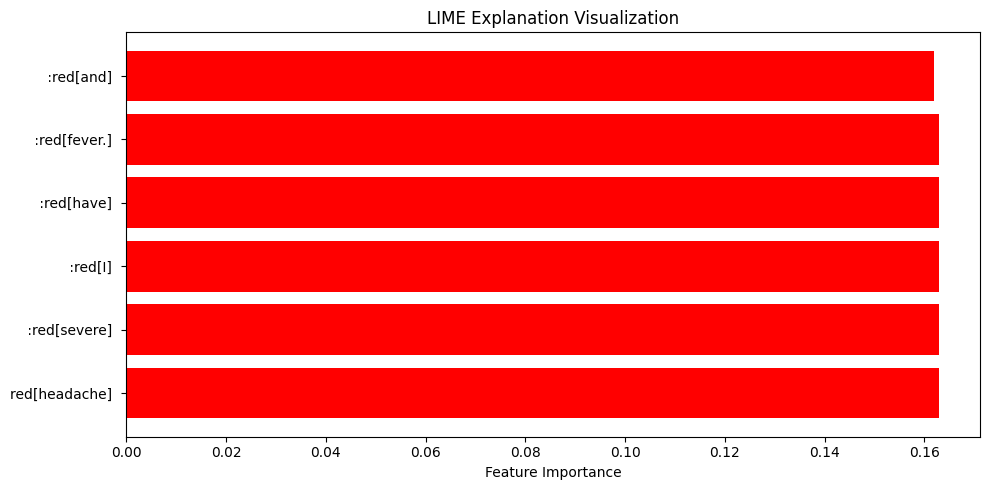


Formatted Explanation:
:red[headache] (0.163) :red[severe] (0.163) :red[I] (0.163) :red[have] (0.163) :red[fever.] (0.163) :red[and] (0.162)


In [6]:
# Test with first example
explanation = visualize_lime_explanation(test_prompts[0], test_responses[0])
print("\nFormatted Explanation:")
print(explanation)

In [7]:
# Function to analyze explanation stability
def test_explanation_stability(prompt, response, num_runs=5):
    """Test stability of LIME explanations across multiple runs"""
    all_explanations = []
    
    for i in range(num_runs):
        print(f"\nRun {i+1}/{num_runs}")
        explanation = lime_explainer.explain_prediction(response, prompt)
        all_explanations.append(explanation)
        
    # Compare explanations
    print("\nStability Analysis:")
    for i, exp in enumerate(all_explanations):
        print(f"\nExplanation {i+1}:")
        print(exp)

In [8]:
# Test stability
test_explanation_stability(test_prompts[1], test_responses[1])


Run 1/5
[LIME] Processing text: The patient shows signs of diabetes and hypertension....
[LIME] Generating explanation...
[LIME] Analyzing 500 samples...
[LIME] Processing explanation...
[LIME] Explanation generated successfully
[LIME] Found 8 significant features

Run 2/5
[LIME] Processing text: The patient shows signs of diabetes and hypertension....
[LIME] Generating explanation...
[LIME] Analyzing 500 samples...
[LIME] Processing explanation...
[LIME] Explanation generated successfully
[LIME] Found 8 significant features

Run 3/5
[LIME] Processing text: The patient shows signs of diabetes and hypertension....
[LIME] Generating explanation...
[LIME] Analyzing 500 samples...
[LIME] Processing explanation...
[LIME] Explanation generated successfully
[LIME] Found 8 significant features

Run 4/5
[LIME] Processing text: The patient shows signs of diabetes and hypertension....
[LIME] Generating explanation...
[LIME] Analyzing 500 samples...
[LIME] Processing explanation...
[LIME] Explana

## Custom Testing

Use this cell to test your own prompts and responses:

Original Prompt: Enter your medical prompt here
Model Response: Enter expected response here

Generating LIME explanation...
[LIME] Processing text: Enter your medical prompt here...
[LIME] Generating explanation...
[LIME] Analyzing 500 samples...
[LIME] Processing explanation...
[LIME] Explanation generated successfully
[LIME] Found 5 significant features


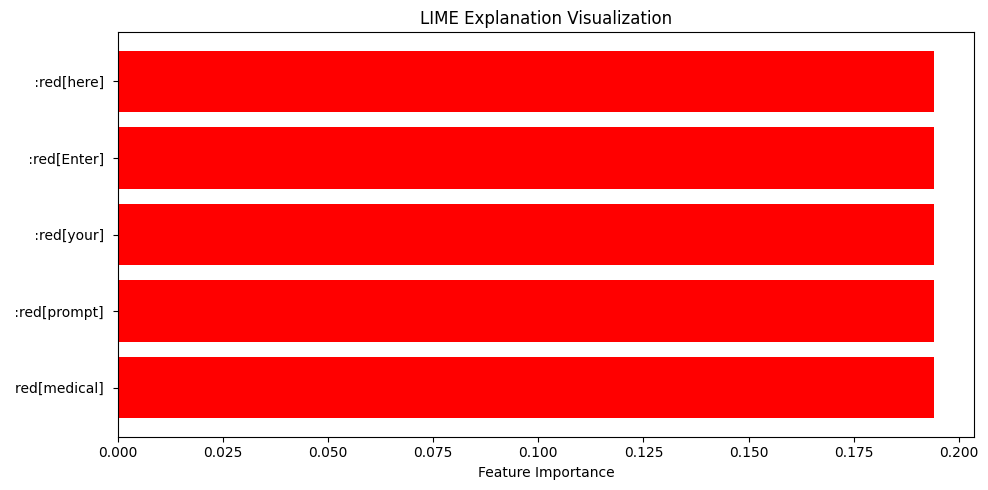

In [9]:
# Test with custom input
custom_prompt = "Enter your medical prompt here"
custom_response = "Enter expected response here"

explanation = visualize_lime_explanation(custom_prompt, custom_response)